In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

# for ML methods and algorithms
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
import sklearn.metrics as sm

# 1) Data wrangling and exploration

In [2]:
# Read the csv | index_col = 0 to get rid of the index count attribute
cardf = pd.read_csv("https://raw.githubusercontent.com/foxdocs/dat-bi/refs/heads/main/Data/cars.csv", index_col=0)

In [3]:
# Size of dataframe
cardf.shape

(2830, 14)

In [4]:
# Attributes and datatypes
cardf.info()

<class 'pandas.DataFrame'>
RangeIndex: 2830 entries, 0 to 2829
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   mpg         2791 non-null   float64
 1   milage      2830 non-null   float64
 2   maketype    2830 non-null   str    
 3   car_id      2830 non-null   int64  
 4   region      2821 non-null   str    
 5   price       2830 non-null   float64
 6   make        2830 non-null   str    
 7   type        2830 non-null   str    
 8   scrapedate  2830 non-null   str    
 9   alder       2830 non-null   int64  
 10  ccm2        2822 non-null   float64
 11  doors       2830 non-null   str    
 12  aldercat    2830 non-null   str    
 13  navn        2821 non-null   str    
dtypes: float64(4), int64(2), str(8)
memory usage: 614.2 KB


In [5]:
# First 3
cardf.head(3)

,mpg,milage,maketype,car_id,region,price,make,type,scrapedate,alder,ccm2,doors,aldercat,navn
0,21.6,18000.0,"Toyota Yaris 1,5 VVT-iE T3 Smart 5d",5559177,København,169900.0,Toyota,Yaris,2022-11-08 22:29:38.772658,3,1500.0,5d,veteran,Region Hovedstaden
1,20.4,254000.0,"Ford Ka 1,2 Trend 3d",4367512,Nordjylland,34900.0,Ford,Ka,2022-11-08 22:29:38.772658,11,1200.0,3d,veteran,Region Nordjylland
2,NaN,51000.0,"Ford Mustang 4,7 V8 289cui. 2d",5506605,København,245000.0,Ford,Mustang,2022-11-08 22:29:38.772658,57,4700.0,2d,veteran,Region Hovedstaden


In [6]:
# 3 Random
cardf.sample(3)

,mpg,milage,maketype,car_id,region,price,make,type,scrapedate,alder,ccm2,doors,aldercat,navn
655,23.7,9300.0,"Ford Fiesta 1,0 EcoBoost mHEV Titanium 5d",5522739,København,174900.0,Ford,Fiesta,2022-11-08 22:29:38.772658,1,1000.0,5d,veteran,Region Hovedstaden
616,28.9,28000.0,"Toyota Aygo 1,0 VVT-i x-sky 5d",5610614,Nordsjælland,109900.0,Toyota,Aygo,2022-11-08 22:29:38.772658,3,1000.0,5d,veteran,Region Sjælland
211,23.3,6500.0,"Ford Focus 1,0 EcoBoost mHEV Titanium 5d",5476728,Vestjylland,249900.0,Ford,Focus,2022-11-08 22:29:38.772658,0,1000.0,5d,veteran,Region Syddanmark


In [7]:
# Range, quantiles and standard devation for attributes with float or int 
cardf.describe()

,mpg,milage,car_id,price,alder,ccm2
count,2791.000000,2830.000000,2.830000e+03,2830.000000,2830.000000,2822.000000
mean,19.818631,100177.604240,5.543292e+06,145862.946643,7.949823,1348.157335
std,4.713819,77699.608577,1.540043e+05,109811.551112,8.636423,554.564514
min,6.900000,0.000000,3.057822e+06,2799.000000,-1.000000,1000.000000
25%,16.100000,41000.000000,5.523972e+06,69800.000000,3.000000,1000.000000
50%,20.800000,87750.000000,5.583950e+06,119900.000000,6.000000,1000.000000
75%,23.300000,143000.000000,5.612806e+06,199500.000000,10.000000,1500.000000
max,39.300000,510300.000000,5.631020e+06,999995.000000,92.000000,5800.000000


### 1.1) Cleaning 

In [8]:
cardf.isna().sum()

mpg           39
milage         0
maketype       0
car_id         0
region         9
price          0
make           0
type           0
scrapedate     0
alder          0
ccm2           8
doors          0
aldercat       0
navn           9
dtype: int64

In [9]:
# Clean/Remove and simplify

# Change miles pr gallon to km. pr liter. also the values: 1 mile - 1.60934 km. and 1 gallon - 3.78541  liter (Done)
# Change milage to km. kørt (Done)
# Remove "make" and "type" from the "maketype" attribute (Done)
# Remove scrapedate | one unique value but keep the scrapedate documented in this notebook (Done)
# Remove d from doors (DONE)

# Remove Region from navn
# Replace aldercat value "veteran" to Ny, Middel, Gammel (DONE)
# replace NaN mpg with mean but groupby with make and type
# remove NaN for region and name
# remove NaN for ccm2 

In [10]:
## Change miles pr gallon to km. pr liter. also the values: 1 mile - 1.60934 km. and 1 gallon - 3.78541  liter
km = 1.60934
liter = 3.78541
factor = km/liter

#New attribute kilometer pr. liter - by multiplying our mpg with the factor
cardf["km/l"] = cardf["mpg"] * factor
#Remove mpg
cardf.drop(columns=["mpg"], inplace=True)
cardf["km/l"].head(2)

0    9.183086
1    8.672914
Name: km/l, dtype: float64

In [11]:
# Change milage to kilometertal - Using km variable from before
cardf["kilometertal"] = cardf["milage"] * km
cardf.drop(columns=["milage"], inplace=True)
cardf["kilometertal"].head(2)

0     28968.12
1    408772.36
Name: kilometertal, dtype: float64

In [12]:
#Making doors without d in the value
cardf['doors'] = cardf['maketype'].str.extract(r'(\d)d')

In [13]:
# Remove "make", "type", "doors" and "ccm2" from the "maketype" attribute using apply and replace for every row
# Make an attribute "model" with the rest
cardf["maketype"] = cardf.apply(lambda x: x["maketype"].replace(x["make"], ""), axis=1)
cardf["maketype"] = cardf.apply(lambda x: x["maketype"].replace(x["type"], ""), axis=1)
cardf["maketype"] = cardf.apply(lambda x: x["maketype"].replace(str(x["doors"])+"d", ""), axis=1)
cardf["maketype"] = cardf.apply(lambda x: x["maketype"].replace(str(x["ccm2"]/1000).replace(".", ","), ""), axis=1)
cardf["model"] = cardf["maketype"]
cardf.drop(columns=["maketype"], inplace=True)
cardf["model"].head(2)

0       VVT-iE T3 Smart 
1                 Trend 
Name: model, dtype: str

In [14]:
# Remove scrapedate | one unique value but keep the scrapedate documented in this notebook
# Scrapedate = 2022-11-08 22:29:38.772658
cardf.drop(columns=["scrapedate"], inplace=True)

In [15]:
#alderskategori ud fra alder (5 kategorier)
#Replace aldercat value "veteran" to Ny, Middel, Gammel (DONE)
bins = [-2, 10, 20, 30, 40, np.inf]
labels = ['moderne', 'ny', 'forholdsvis ny', 'gammel', 'meget gammel']
cardf['aldercat'] = pd.cut(cardf['alder'], bins=bins, labels=labels)

#Remove Region from navn
cardf['navn'] = cardf['navn'].str.replace("Region", "")

In [94]:
## Kategori variabel ift. ccm2
e_bins = [0, 1200, 1600, 2000, np.inf]
e_labels = ['meget økonomisk', 'økonomisk', 'mindre økonomisk', 'uøkonomisk']
cardf['benzin_økonomi'] = pd.cut(cardf['ccm2'], bins=e_bins, labels=e_labels)

#### replace NaN mpg with mean but groupby with make and type

Because there were some makers that only had one of the type which had nan mpg, there were no mean value for it to enter
So we had to split it up, by finding the mean for the makers that had enough types to calculate a mean
And afterwards we took the overall mean of mpg and assigned the rest nan values with those
We thought it were the best solution, and not just removing them
group mean

In [17]:
# group mean
group_mean = cardf.groupby(['make', 'type'])['km/l'].transform('mean')

# overall mean
overall_mean = cardf['km/l'].mean()

#fill first with group mean, then overall mean
cardf['km/l'] = cardf['km/l'].fillna(group_mean).fillna(overall_mean)

#remove NaN for region and name & remove NaN for ccm2
cardf.dropna(subset=['region', 'navn', 'ccm2'], inplace=True)

In [18]:
# Checking for NaN again
cardf.isna().sum()

car_id            0
region            0
price             0
make              0
type              0
alder             0
ccm2              0
doors             0
aldercat          0
navn              0
km/l              0
kilometertal      0
model             0
benzin_økonomi    0
dtype: int64

In [19]:
# Checking for duplicates
cardf.duplicated().sum()

np.int64(0)

### outliers by interquartile range (IQR)

In [20]:
from typing import List
def remove_outliers(df, data: List):
    q1 = data.quantile(.25)
    q3 = data.quantile(.75)
    IQR = q3 - q1
    # values smaller than 1.5 IQR below q1 and bigger that 1.5 IQR over q3 
    outliers = df[(data < (q1 - 1.5 * IQR)) | (data > (q3 + 1.5 * IQR))]
    df = df.drop(outliers.index)
    return df
remove_outliers(cardf, cardf[['ccm2', 'km/l', 'kilometertal', 'price']])

,car_id,region,price,make,type,alder,ccm2,doors,aldercat,navn,km/l,kilometertal,model,benzin_økonomi


Select and analyse the features of a car, which would be most relevant for solving the following
machine learning tasks: 

We want to analyze which attributes has an effect on price. We made a lot of graphs and kept the ones with a tendency.

<Axes: title={'center': 'Price Decreases as Kilometertal Increases'}, xlabel='price', ylabel='kilometertal'>

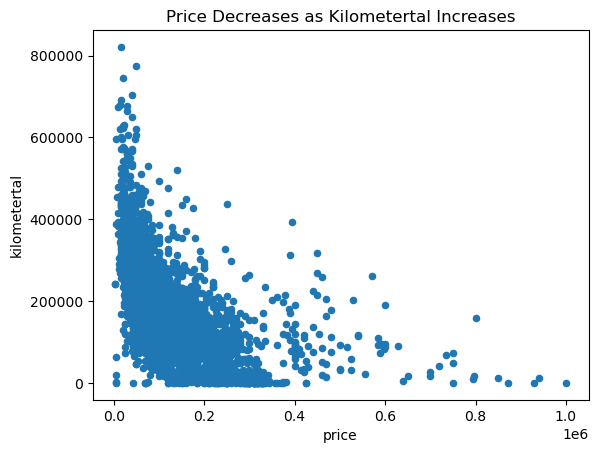

In [21]:
  cardf.plot.scatter(x='price', y='kilometertal', title="Price Decreases as Kilometertal Increases")

<Axes: xlabel='price', ylabel='alder'>

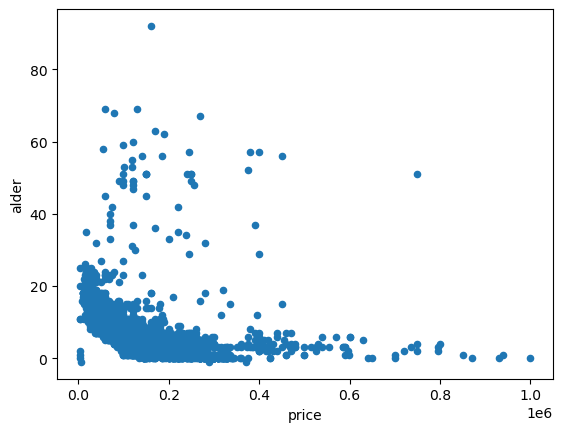

In [22]:
#We can observe the price of the car generally is lower when the age of the car is older.
cardf.plot.scatter(x='price', y='alder')

In [87]:
# The most popular make and type
popular = cardf.groupby(["make", "type"]).size().sort_values(ascending=False).index[0]

In [88]:
# We want the attributes values only from the Ford Fiesta
cardf[(cardf["make"] == popular[0]) & (cardf["type"] == popular[1])].iloc[0]

car_id                            5518776
region                       Nordsjælland
price                            169700.0
make                                 Ford
type                               Fiesta
alder                                   2
ccm2                               1000.0
doors                                   5
aldercat                          moderne
navn                             Sjælland
km/l                            11.393828
kilometertal                      16093.4
model                EcoBoost Titanium X 
benzin_økonomi                 uøkonomisk
cluster                                 2
price_segment                        High
Name: 8, dtype: object

In [91]:
# Looking for tendency in the preference of the car models during the past 5-10 years?

recent = cardf[cardf["alder"] <= 10]
recent.groupby(["alder","type"]).size().unstack()
# It shows Fiesta is quite popular throughout the 10 years, but we can see a tendency from 10-years to now that
# the amount is growing. Yaris and Aygo appears more often from 5 years to now, but with some outliers like Aygo 7 years ago

type,Auris,Avensis,Aygo,B-MAX,C-HR,C-MAX,Corolla,EcoSport,F-150,Fiesta,...,V60,V70,V90,Verso,Verso-S,XC40,XC60,XC70,XC90,Yaris
alder,,,,,,,,,,,,,,,,,,,,,
-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,27.0,NaN,NaN,NaN,NaN,NaN,NaN,51.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,8.0
1,NaN,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,41.0,...,3.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,13.0
2,NaN,NaN,33.0,NaN,NaN,NaN,1.0,NaN,NaN,16.0,...,6.0,NaN,NaN,NaN,NaN,4.0,2.0,NaN,NaN,22.0
3,NaN,NaN,48.0,NaN,NaN,5.0,1.0,1.0,NaN,59.0,...,3.0,NaN,1.0,NaN,NaN,10.0,10.0,NaN,NaN,56.0
4,NaN,5.0,25.0,NaN,1.0,14.0,NaN,11.0,1.0,70.0,...,3.0,NaN,2.0,3.0,NaN,4.0,2.0,NaN,1.0,13.0
5,1.0,6.0,46.0,NaN,1.0,15.0,NaN,NaN,NaN,44.0,...,3.0,NaN,1.0,5.0,NaN,NaN,1.0,NaN,NaN,17.0
6,5.0,16.0,24.0,4.0,1.0,12.0,NaN,NaN,NaN,46.0,...,1.0,NaN,NaN,7.0,NaN,NaN,1.0,1.0,3.0,14.0
7,8.0,16.0,90.0,3.0,NaN,12.0,NaN,NaN,NaN,54.0,...,1.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,28.0


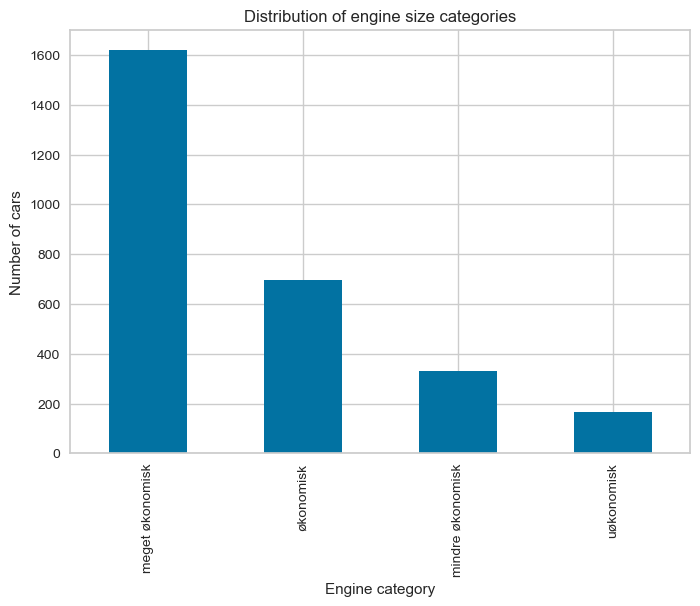

In [95]:
cardf['benzin_økonomi'].value_counts().plot(kind='bar')
plt.title("Distribution of engine size categories")
plt.xlabel("Engine category")
plt.ylabel("Number of cars")
plt.show()

# 2) Supervised machine learning by regression

### 2.1) Define dependent and independent attributes of a car

In [25]:
# First we define the variable that we want to explore and is dependent
y = cardf['price']
X = cardf[['kilometertal','ccm2', 'km/l', 'alder']]

<Axes: >

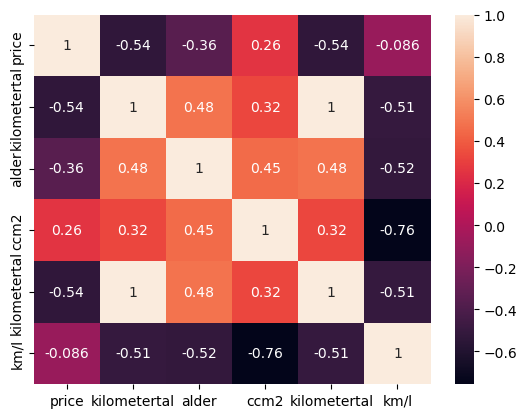

In [26]:
# We use pearson correlation
corr = cardf[['price','kilometertal','alder','ccm2','kilometertal', 'km/l']].corr()
sbn.heatmap(corr, annot=True)

The heatmat shows moderat correlation such as:

* km/l and ccm2/slagvolume (-0.76)
* kilometertal and price (-0.54)
* km/l and alder (-0.52)
* km/l and kilometertal (0.-51)
* kilometertal and alder (0.48)
* alder and ccm2 (0.45)
* price and alder (-0.36)

### 2.2) Train, test, and validate ML model for prediction of the values of the dependent variables, such as price or economy

In [27]:
# We are splitting our Dataframe 80/20, 80% for training purposes and 20% for testing purposes
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123, test_size=0.20) 
  
myreg = LinearRegression()

In [28]:
# fitting it to our data
myreg.fit(X_train, y_train)
myreg  

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
# getting the calculated coefficients
a = myreg.coef_
b = myreg.intercept_
print(f"The model is a line \n\ty = a * x + b, or\n\ty = {a} * x + {b}")

The model is a line 
	y = a * x + b, or
	y = [-5.60129504e-01  8.69400718e+01 -1.61573048e+04 -5.32915230e+03] * x + 297262.0713520021


In [30]:
#
y_predicted = myreg.predict(X_test)
y_predicted

array([ 162984.92137686,  191809.47275805,  238530.82327668,
        235114.70446841,  171418.89704698,   13109.72756783,
        133766.04716009,  222263.29931374,  263946.72504691,
        166142.50039889,  118038.40746914,  158627.41051182,
        232651.34204563,  132034.43474206,  238530.82327668,
         78960.80641329,  238612.1663078 ,  215264.09084785,
         50697.47624733,   86058.84340358,   79924.9630673 ,
         86945.84021761,  116007.42614681,  240207.5989059 ,
        244529.86122478,  -20150.2702063 ,   -3894.94989694,
        111136.39033491,  219783.31971898,  281956.45828565,
        193540.08641038,  180016.10572544,  199929.63872014,
        130682.80721777,  174576.0387407 ,  228530.02241687,
        302666.00900171,  182181.31575776,   71710.29805381,
        181163.38091025,   85196.27900271,  -38593.10324363,
        215746.2988612 ,  180194.25819588,   68748.75579763,
         22138.92615675,  124543.49340237,  242066.41508548,
        225280.87032173,

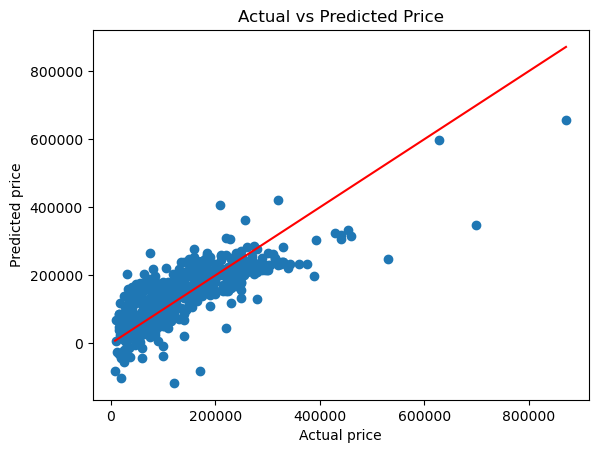

In [31]:
# Visualising the Linear Regression 
# The scatter plot show predicted vs actual price. The dots represents each car 
# The red line shows a perfect prediction
# We can see from the plot that predictions ain't perfect, but it's not too bad either
plt.scatter(y_test, y_predicted)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted Price")
plt.show()

In [32]:
# Testing if the model can predict price by values: kilometertal, ccm2, km/l, alder
new_car = [[120000, 3000, 10.28, 20]]  

predicted_price = myreg.predict(new_car)

print(predicted_price)

[218186.60683614]


C:\Users\Bruger\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [33]:
## - apply appropriate error measures for assessing the quality of the model 
  
# We are calculating the error measures
 
# MAE
from sklearn import metrics
mae = metrics.mean_absolute_error(y_test, y_predicted)
print(mae)
# out put is: 48061.378942819334 which means that the model calculates 48061.4 wrong in the price

48061.37894281934


In [34]:
# MSE
#MSE measures the average squared prediction error
#It penalizes large errors more heavily than MAE
mse = metrics.mean_squared_error(y_test, y_predicted)
print(mse)

4015105119.1262307


In [35]:
# RMSE
# RMSE is the square root of MSE and represents the typical size of prediction errors 
# in the same unit as price
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_predicted))
print(rmse)

63364.857130165066


Our model has a Root Mean Squared Error of around 63365kr which means the mean of the predicted car price is off by 63365kr which is a lot.

In [68]:
from sklearn.metrics import r2_score
# The R² score indicates how much of the variation in car prices is explained by the model
# The model explains approximately 60% of the variation in car prices
r2 = r2_score(y_test, y_predicted)
print("R2:", r2)

ValueError: could not convert string to float: 'Low'

The r2 value explains how much variation of the price the model can explain. The model still missing 40% which can be explained because we only took the numeric values and are still missing some factors like make, type, ccm2 etc.

# 3) Unsupervised machine learning for clustering

### 3.1) apply a clustering algorithm for segmentation of the vehicles from the data source in groups of
### similarity

In [37]:
!pip install yellowbrick

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
from yellowbrick.cluster import SilhouetteVisualizer
import joblib

# For segmentation and clustering we want to look at the variables kilometertal, ccm2, km/l, alder and price 
# We are choosing the K-means algorithm for our clustering and segmentation 
X_cluster = cardf[["kilometertal","ccm2","km/l","alder","price"]].values

# K-Means distance based so we need to scale so all our variables is available
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

### 3.1) Elbow method

In [39]:
# Determine k by minimizing the distortion - 
# the sum of the squared distances between each observation vector and its centroid
distortions = []
K = range(2, 10)
for k in K:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(X_scaled)
    distortions.append(sum(np.min(cdist(X_scaled, model.cluster_centers_, 'euclidean'), axis=1)) / X_scaled.shape[0])
    # print all distortions to identify the lowest gain
print("Distortion: ", distortions)

Distortion:  [np.float64(1.5128945294213703), np.float64(1.3050510688097234), np.float64(1.233688127687075), np.float64(1.0866645674837443), np.float64(1.0156530765684892), np.float64(0.9469895250906527), np.float64(0.9136788052866742), np.float64(0.8658772789255781)]


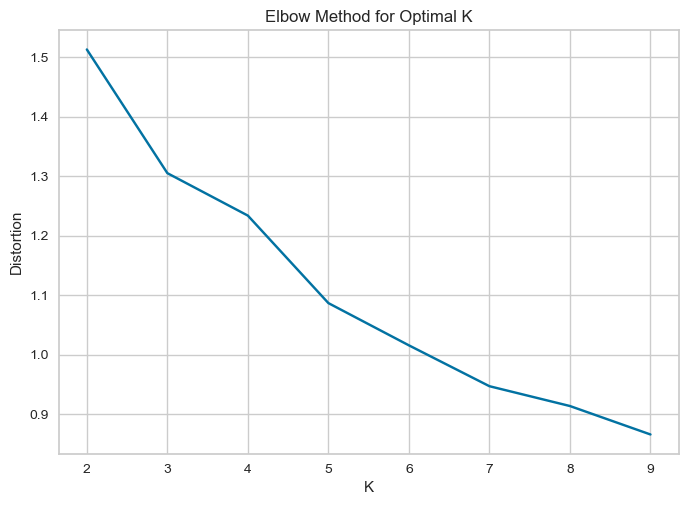

In [40]:
# Plotting the distortion to discover the elbow
plt.title('Elbow Method for Optimal K')
plt.plot(K, distortions, 'bx-')
plt.xlabel('K')
plt.ylabel('Distortion')
plt.show()

### 3.2) Determin K by Silhouette Score
A silhouette score is a measure of clusterts quality in terms of cohesion (small distance between the data in one cluster) and separation (large distance between the clusters).
It is calculated for each point separately and then as an average value of the individual scores.
The value is a number [-1, +1]. The best result is 1, while -1 means wrong clustering. The peripherial points in a cluster would produce result close to 0.
We can apply the method for choosing the right number of clusters, as well as for comparing different methods of clustering. We always search for the maximum silhouette score.

Number of clusters = 2, Silhouette Score = 0.451
Number of clusters = 3, Silhouette Score = 0.309
Number of clusters = 4, Silhouette Score = 0.325
Number of clusters = 5, Silhouette Score = 0.340
Number of clusters = 6, Silhouette Score = 0.354
Number of clusters = 7, Silhouette Score = 0.312
Number of clusters = 8, Silhouette Score = 0.322
Number of clusters = 9, Silhouette Score = 0.315


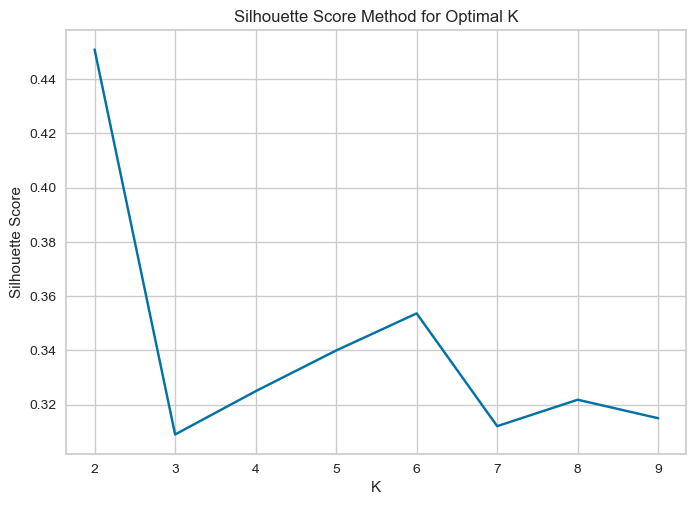

In [41]:
scores = []
for k in K:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(X_scaled)
    score = silhouette_score(X_scaled, model.labels_)
    print(f'Number of clusters = {k}, Silhouette Score = {score:.3f}')
    scores.append(score)

# Plotting the elbow 
plt.plot(K, scores, 'bx-')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Method for Optimal K')
plt.show()

### 3.3) Train Model

In [42]:
# Optimal number of clusters K (seems to be 5)
num_clusters = 5

# Creating an instance of KMeans classifier
kmeans = KMeans(n_clusters=num_clusters, n_init=20, random_state=42)
# n_init: the algorithm will run n_init times with different cetroids and the best result of those will be taken

# Train the KMeans clustering model
kmeans.fit(X_scaled)

,n_clusters,5
,init,'k-means++'
,n_init,20
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [43]:
# Saving cluster in labels in our cardf
cardf['cluster'] = kmeans.labels_

### 3.3) Visualising 

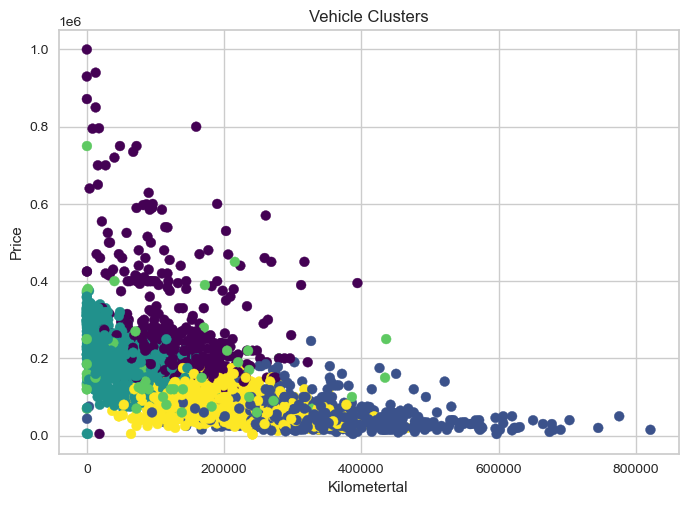

In [44]:
# Scatter plot of kilometertal and price with clusters
plt.scatter(cardf["kilometertal"], cardf["price"], c=cardf["cluster"], cmap='viridis', s=50)
plt.xlabel('Kilometertal')
plt.ylabel('Price')
plt.title('Vehicle Clusters')
plt.show()

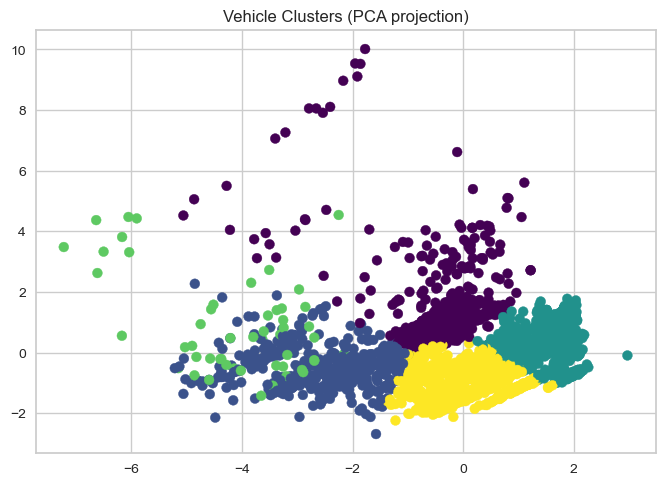

In [45]:
# To visualize all 5 variables we use PCA 
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=cardf['cluster'], cmap='viridis', s=50)
plt.title('Vehicle Clusters (PCA projection)')
plt.show()

In [46]:
# Validate Model
k = 5
model = KMeans(n_clusters=k, n_init=10)
model.fit_predict(X)

array([2, 4, 0, ..., 0, 3, 3], shape=(2813,), dtype=int32)

In [47]:
score = silhouette_score(X, model.labels_, metric='euclidean')
print('Silhouette Score: %.3f' % score)

Silhouette Score: 0.556


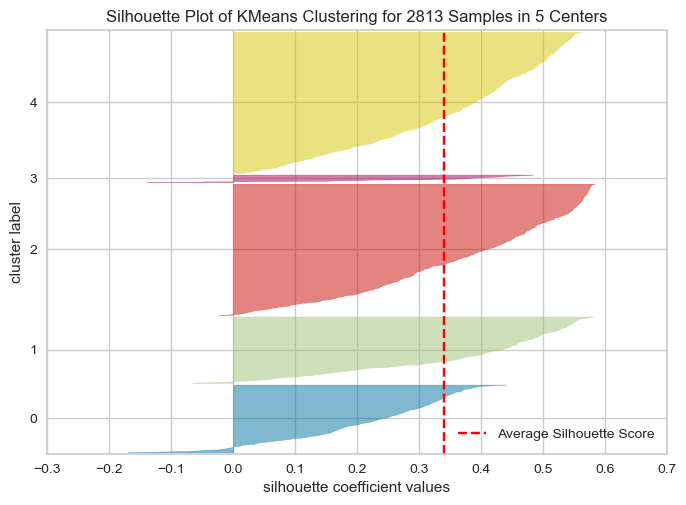

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 2813 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [48]:
# We also want to visualize our Silhouette score to see if the clusters are close or have distance to eachother
# Visualize the silhouette scores of all points
visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick')
visualizer.fit(X_scaled)
visualizer.show()

Interpretation: Each component of the figure represents one cluster with a horisontal bar chart of each cluster point.
Clusters are seen almost equaly tick and long - similar. There is no cluster with a silhouette score lower than the average (the red line).
The score is bigger than 0.5 - relatively good.

### 3.4) Train with new data

In [49]:
# Defining 2 new cars with Attributes: kilometertal, ccm2, km/l, alder, price
test1 = np.array([[58800, 1600, 15, 3, 120000]]) # new car 1
test2 = np.array([[60000, 2000, 20, 2, 80000]]) # new car 2

# Standardize with the same scaler used for training
scaled_test1 = scaler.transform(test1)
scaled_test2 = scaler.transform(test2)


# Predict cluster labels
cluster1 = kmeans.predict(scaled_test1)
cluster2 = kmeans.predict(scaled_test2)

print(cluster1, cluster2)

[2] [2]


In [58]:
# If we want to implement supervised learning and want to see the different clusters mean, we can categorize them, e.g both our test was cluster 2 
# was cluster [2]. The ranges and values/Segment for cluster 2 is low kilometertal(around 47), low ccm2, low alder, high price. Showed below.
numeric_cols = ['kilometertal','ccm2','km/l','alder','price']  
cluster_summary = cardf.groupby('cluster')[numeric_cols].mean()
print(cluster_summary)

          kilometertal         ccm2      km/l      alder          price
cluster                                                                
0        134415.134546  1827.826087  6.604550   5.334783  272755.515217
1        350792.739030  1870.907080  5.668509  15.884956   54133.019912
2         46960.030040  1054.769921  9.877629   2.215488  194954.951740
3        127773.239812  2486.538462  5.517573  50.384615  184973.884615
4        193143.987599  1077.818372  9.348039   7.965553   80924.094990


In [60]:
# We are adding cluster column to our dataframe. Cluster start in index 0 so its 0-4. After supervised classification 
# we can look at cluster and price segment to see if they are comparable.
cardf['cluster'] = kmeans.predict(X_scaled)


,car_id,region,price,make,type,alder,ccm2,doors,aldercat,navn,km/l,kilometertal,model,benzin_økonomi,cluster,price_segment
0,5559177,København,169900.0,Toyota,Yaris,3,1500.0,5,moderne,Hovedstaden,9.183086,28968.12,VVT-iE T3 Smart,uøkonomisk,2,High
1,4367512,Nordjylland,34900.0,Ford,Ka,11,1200.0,3,ny,Nordjylland,8.672914,408772.36,Trend,uøkonomisk,4,Low
2,5506605,København,245000.0,Ford,Mustang,57,4700.0,2,meget gammel,Hovedstaden,4.262451,82076.34,V8 289cui.,uøkonomisk,3,Very high
3,5518799,København,29999.0,Toyota,Avensis,18,1800.0,5,ny,Hovedstaden,5.909486,395897.64,VVT-i Sol stc.,uøkonomisk,1,Low
4,5604536,Nordjylland,199900.0,Volvo,V40,5,2000.0,5,moderne,Nordjylland,7.610057,156105.98,T2 122 Momentum Eco,uøkonomisk,0,Very high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2825,4129676,Østjylland,99900.0,Ford,Taunus,51,2000.0,2,meget gammel,Midtjylland,5.654400,236572.98,17M RS,uøkonomisk,3,Medium
2826,4093027,Østjylland,59900.0,Ford,Zephyr,69,2300.0,4,meget gammel,Midtjylland,8.425749,138403.24,Six Saloon,uøkonomisk,3,Low
2827,3583029,Vestjylland,59900.0,Ford,Ka,18,1600.0,2,ny,Syddanmark,5.399314,170590.04,Street,uøkonomisk,1,Low
2828,3455814,Østjylland,219900.0,Toyota,Corolla,35,1600.0,3,gammel,Midtjylland,5.526857,204386.18,GT Coupé,uøkonomisk,3,Very high


# 4. Supervised machine learning for classification

In [51]:
# - train, test, and validate a machine learning model for classification of a car in a proper price segment 
# We use qcut instead of cut because of the unbalanced categories it gave us, so we only had an accuracy on 5%, so we use qcut to balance the groups, so now er get 83%
labelsss = ['Low', 'Medium', 'High', 'Very high']

cardf['price_segment'] = pd.qcut(cardf['price'], q=4, labels= labelsss)

  # We define the independent variables
X = cardf[['kilometertal', 'ccm2', 'km/l', 'alder']]
  # We define the variable that we want to explore and is dependent
y = cardf['price_segment']

# We are splitting our Dataframe 80/20, 80% for training purposes and 20% for testing purposes
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123, test_size=0.20)

from sklearn.ensemble import RandomForestClassifier

# Creating the classification model
# random_state does so we get the same results every time we run it
clf = RandomForestClassifier(random_state=123)

# Training the model using our training data, X_train gets to know the relation to y_train
clf.fit(X_train, y_train) 

# Using the model we've trained to predict the price segment for out test data
y_pred = clf.predict(X_test)

# - apply appropriate methods for measuring of the accuracy of the classification model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy tells us how many of the prediction were correct
# We got 0.83 so it's 83%
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.8330373001776199


In [52]:
# Shows more detailed information about the performance of the model
# It shows how well a job the model does of predicting the price segments
print("\nClassification report:")
print(classification_report(y_test, y_pred))


Classification report:
              precision    recall  f1-score   support

        High       0.88      0.74      0.80       142
         Low       0.80      0.89      0.85       132
      Medium       0.79      0.78      0.78       151
   Very high       0.88      0.93      0.90       138

    accuracy                           0.83       563
   macro avg       0.84      0.84      0.83       563
weighted avg       0.83      0.83      0.83       563



In [53]:
# Shows how many cars were placed correctly and incorrectly
# It gives us information about where it goes wrong
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion matrix:
[[105   2  17  18]
 [  0 118  14   0]
 [  8  25 118   0]
 [  7   2   1 128]]


In [54]:
print(cardf['price_segment'].value_counts())

price_segment
Medium       715
Low          705
Very high    703
High         690
Name: count, dtype: int64


In [96]:
# Checking region compared to very high price segment
cardf.groupby(["region", "price_segment"]).size().unstack()

price_segment,Low,Medium,High,Very high
region,,,,
Fyn,85,68,61,46
København,125,105,94,147
Lolland-Falster,9,1,3,1
Nordjylland,84,61,69,53
Nordsjælland,40,39,34,45
Syd- og Sønderjylland,74,136,147,150
Syd- og Vestsjælland,125,151,115,92
Vestjylland,34,37,42,58
Østjylland,129,117,125,111


# 5) Decision Tree

In [63]:
# We are adding decision tree to observe and visualize accuracy if we only have one tree instead of multiple.
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=4, random_state=123)

dt.fit(X_train, y_train)

y_pred_tree = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
#The Decision Tree Accuracy compared to Random Forest Accuracy is lower because Random Forest makes a lot of decision trees,
# takes the average and reduce overfitting

Decision Tree Accuracy: 0.6234458259325044


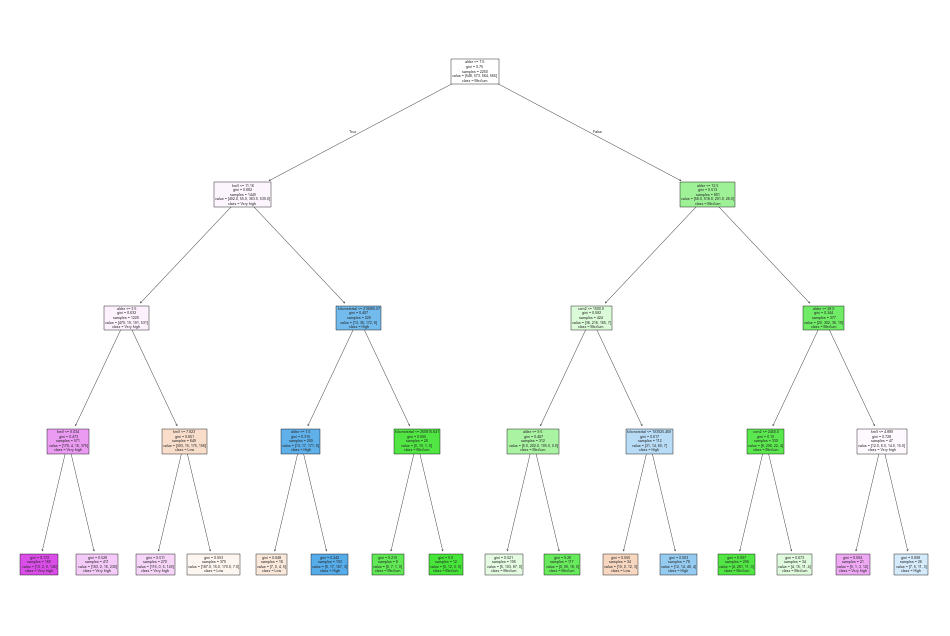

In [65]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
# Our plot shows when decision is being taken because of the value of the attribute.
plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=X.columns, class_names=labelsss, filled=True)
plt.show()

In [67]:
#We also want to look into what variables had the most affect on making the price_segment.
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf.feature_importances_
})

print(importance.sort_values(by="Importance", ascending=False))

        Feature  Importance
3         alder    0.314741
2          km/l    0.298991
0  kilometertal    0.282510
1          ccm2    0.103758


# 6) Store models in a file

In [69]:
# Cluster k-mean model
joblib.dump(kmeans, 'kmeans_vehicle_model.pkl')

['kmeans_vehicle_model.pkl']

In [56]:
#
model_file = 'mylinfit.pkl'
joblib.dump(myreg, model_file)
my_model = joblib.load(model_file)

In [70]:
#Storing the model in a file
model_file = 'mylinfit.pkl'
#Saving the model
joblib.dump(myreg, model_file)
#To load it later for usage
my_model = joblib.load(model_file)
#Evaluating the model
y_predict = my_model.predict(X_test)
#Testing the loaded model
price_prediction = my_model.predict([[120000, 3000, 10.28, 20]])
print(price_prediction)

[218186.60683614]


C:\Users\Bruger\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


The reason why we're saving the models, is because the alternative would be to run the whole code again, if the machine needs two hours of training every time, then we'll have to wait. But by simply saving it, we can load it from another file by import joblib and importing the model that has been saved on the computer in a file